In [ ]:
# !pip install hpsv3

In [ ]:
# !pip install hpsv2x

In [ ]:
from datasets import load_dataset

ds1 = load_dataset("weathon/aas_benchmark-nano-banana")
ds2 = load_dataset("weathon/aas_benchmark-qwen_image")
ds3 = load_dataset("weathon/aas_benchmark-gpt-image-mini")
ds4 = load_dataset("weathon/aas_benchmark-gpt-image-mini-high")
ds5 = load_dataset("weathon/aas_benchmark-seeddream4")
ds6 = load_dataset("weathon/aas_benchmark-stable_diffusion_xl")
ds7 = load_dataset("weathon/aas_benchmark-stable_diffusion_1.5")
ds8 = load_dataset("weathon/aas_benchmark-flux_krea")
ds9 = load_dataset("weathon/aas_benchmark-grpo_flux")
ds10 = load_dataset("weathon/aas_benchmark-playground")
ds11 = load_dataset("weathon/aas_benchmark-sd3_medium_grpo")
ds12 = load_dataset("weathon/aas_benchmark-stable_diffusion_3.5_medium")
ds13 = load_dataset("weathon/aas_benchmark-stable_diffusion_3.5_large")

In [ ]:
# concate the dataset
from datasets import concatenate_datasets

ds = concatenate_datasets([ds1["train"], ds2["train"], ds3["train"], ds4["train"], ds5["train"], ds6["train"], ds7["train"], ds8["train"], ds9["train"], ds10["train"], ds11["train"], ds12["train"], ds13["train"]])

In [ ]:
ds = ds.filter(lambda example: example["index"] != 13)

In [ ]:
# from datasets import load_dataset

# ds = load_dataset("weathon/aas_benchmark-all")

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'hpsv2_original', 'hpsv2_distorted', 'rater_scores', 'llm_original_reasoning', 'llm_original_main_concepts', 'llm_original_special_effects', 'llm_distorted_reasoning', 'llm_distorted_main_concepts', 'llm_distorted_special_effects', 'image_original', 'image_distorted', 'model'],
    num_rows: 2587
})

In [ ]:
# from hpsv3 import HPSv3RewardInferencer

# inferencer = HPSv3RewardInferencer(device='cuda')

In [ ]:
# import torch
# idx = 384
# image_paths = [ds[idx]["image_original"], ds[idx]["image_original"], ds[idx]["image_distorted"]]
# prompts = [
#   ds[idx]["prompt_original"],
#   ds[idx]["prompt_distorted"],
#   ds[idx]["prompt_distorted"]
# ]

# with torch.no_grad():
#   rewards = inferencer.reward(prompts=prompts, image_paths=image_paths)
# scores = [reward[0].item() for reward in rewards]  # Extract mu values
# print(f"Image scores: {scores}")

In [ ]:
# rewards

In [ ]:
# ds

In [ ]:
# def hpsv3_reward(sample):
#   with torch.no_grad():
#     images = [sample["image_original"], sample["image_original"], sample["image_distorted"]]
#     prompts = [
#       sample["prompt_original"],
#       sample["prompt_distorted"],
#       sample["prompt_distorted"]
#     ]
#     rewards = inferencer.reward(prompts=prompts, image_paths=images)
#   sample["hpsv3"] = rewards.cpu().detach().numpy().flatten()
#   return rewards

In [ ]:
# ds = ds.map(hpsv3_reward, num_proc=1)

In [ ]:
import pickle
with open("hpsv3.pkl", "rb") as f:
  rewards = pickle.load(f)

In [ ]:
# rewards = []
# import tqdm
# for sample in tqdm.tqdm(ds):
#   rewards.append(hpsv3_reward(sample))


In [ ]:
ds = ds.add_column("hpsv3", [i.cpu().detach().numpy().flatten() for i in rewards])

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'hpsv2_original', 'hpsv2_distorted', 'rater_scores', 'llm_original_reasoning', 'llm_original_main_concepts', 'llm_original_special_effects', 'llm_distorted_reasoning', 'llm_distorted_main_concepts', 'llm_distorted_special_effects', 'image_original', 'image_distorted', 'model', 'hpsv3'],
    num_rows: 2587
})

In [ ]:
import pickle
with open("hpsv3.pkl", "wb") as f:
  pickle.dump(rewards, f)

In [ ]:
def condense_llm_columns(sample):
  sample["llm_rater"] = {
      "llm_original_reasoning": sample["llm_original_reasoning"],
      "llm_distorted_reasoning": sample["llm_distorted_reasoning"],
      "llm_original_main_concepts": sample["llm_original_main_concepts"],
      "llm_distorted_main_concepts": sample["llm_distorted_main_concepts"],
      "llm_original_special_effects": sample["llm_original_special_effects"],
      "llm_distorted_special_effects": sample["llm_distorted_special_effects"],
  }
  return sample

ds = ds.map(condense_llm_columns)

Map:   0%|          | 0/2587 [00:00<?, ? examples/s]

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'hpsv2_original', 'hpsv2_distorted', 'rater_scores', 'llm_original_reasoning', 'llm_original_main_concepts', 'llm_original_special_effects', 'llm_distorted_reasoning', 'llm_distorted_main_concepts', 'llm_distorted_special_effects', 'image_original', 'image_distorted', 'model', 'hpsv3', 'llm_rater'],
    num_rows: 2587
})

In [ ]:
ds = ds.remove_columns(["llm_original_reasoning", "llm_distorted_reasoning", "llm_original_main_concepts", "llm_distorted_main_concepts", "llm_original_special_effects", "llm_distorted_special_effects"])

In [ ]:
ds = ds.remove_columns(["hpsv2_original", "hpsv2_distorted"])

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'rater_scores', 'image_original', 'image_distorted', 'model', 'hpsv3', 'llm_rater'],
    num_rows: 2587
})

In [ ]:
# ds.push_to_hub("weathon/aas_benchmark-all")

In [ ]:
# from datasets import load_dataset

# ds = load_dataset("weathon/aas_benchmark-all", download_mode="force_redownload")

In [ ]:
# import hpsv2
# import torch

# def hpsv2_reward(sample):
#   with torch.no_grad():
#     images = [sample["image_original"], sample["image_original"], sample["image_distorted"]]
#     prompts = [
#       sample["prompt_original"],
#       sample["prompt_distorted"],
#       sample["prompt_distorted"]
#     ]

#     rewards = [hpsv2.score(image, prompt, hps_version="v2.1") for image, prompt in zip(images, prompts)]
#   return rewards

In [ ]:
# rewards = []
# import tqdm
# for sample in tqdm.tqdm(ds["train"]):
#   rewards.append(hpsv2_reward(sample))

In [ ]:
# import pickle
# with open("rewards.pkl", "wb") as f:
#   pickle.dump(rewards, f)

In [ ]:
with open("hpsv2.pkl", "rb") as f:
  rewards = pickle.load(f)

In [ ]:
ds = ds.add_column("hpsv2", rewards)

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'rater_scores', 'image_original', 'image_distorted', 'model', 'hpsv3', 'llm_rater', 'hpsv2'],
    num_rows: 2587
})

In [ ]:
# ds.push_to_hub("weathon/aas_benchmark-all")


In [ ]:
from datasets import load_dataset

ds = load_dataset("weathon/aas_benchmark-all")

README.md:   0%|          | 0.00/1.04k [00:00<?, ?B/s]

train-00000-of-00012.parquet:   0%|          | 0.00/669M [00:00<?, ?B/s]

train-00001-of-00012.parquet:   0%|          | 0.00/797M [00:00<?, ?B/s]

train-00002-of-00012.parquet:   0%|          | 0.00/644M [00:00<?, ?B/s]

train-00003-of-00012.parquet:   0%|          | 0.00/705M [00:00<?, ?B/s]

...

train-00008-of-00012.parquet:   0%|          | 0.00/596M [00:00<?, ?B/s]

train-00009-of-00012.parquet:   0%|          | 0.00/266M [00:00<?, ?B/s]

train-00010-of-00012.parquet:   0%|          | 0.00/154M [00:00<?, ?B/s]

train-00011-of-00012.parquet:   0%|          | 0.00/159M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2587 [00:00<?, ? examples/s]

In [ ]:
ds = ds.remove_columns(["image_original", "image_distorted"])

In [ ]:
import numpy as np
original_scores = np.array([i[2] for i in ds["hpsv3"]])
distorted_scores = np.array([i[4] for i in ds["hpsv3"]])

In [ ]:
original_scores_llm = np.array([i["llm_original_special_effects"] for i in ds["llm_rater"]])
distorted_scores_llm = np.array([i["llm_distorted_special_effects"] for i in ds["llm_rater"]])

In [ ]:
worked = original_scores_llm < distorted_scores_llm
worked_delta_score = (distorted_scores - original_scores)[worked]

In [ ]:
from scipy.stats import spearmanr
spearmanr(distorted_scores_llm - original_scores_llm, distorted_scores - original_scores)

SignificanceResult(statistic=np.float64(-0.15177375459406797), pvalue=np.float64(8.434888558426747e-15))

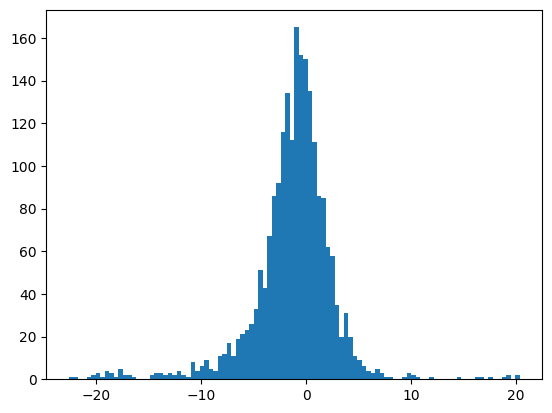

In [ ]:
import pylab
pylab.hist(worked_delta_score, bins=100)
pylab.show()

In [ ]:
wilcoxon(worked_delta_score, alternative='two-sided', method='asymptotic')

WilcoxonResult(statistic=np.float64(688392.0), pvalue=np.float64(1.576024229575331e-55))

In [ ]:
import numpy as np
from scipy.stats import wilcoxon
from scipy.stats import norm

T, p_two_sided = wilcoxon(worked_delta_score, alternative='two-sided', method = 'asymptotic')
N = len(worked_delta_score)
Z_approx = -norm.ppf(p_two_sided / 2.0)
median_diff = np.median(worked_delta_score)
Z = np.abs(Z_approx) * np.sign(median_diff)

if N > 0:
    r = Z / np.sqrt(N)
else:
    r = np.nan

if median_diff < 0:
    p_one_sided = p_two_sided / 2.0
else:
    p_one_sided = 1.0 - (p_two_sided / 2.0)

print(f"N: {N}")
print(f"Median Delta Var2: {median_diff}")
print(f"Z-statistic (Signed): {Z}")
print(f"P-value (one-sided, less): {p_one_sided:.4f}")
print(f"Effect Size r: {r:.4f}")

N: 2129
Median Delta Var2: -0.8682804107666016
Z-statistic (Signed): -15.697386484809817
P-value (one-sided, less): 0.0000
Effect Size r: -0.3402
